Dataset shape: (5000, 11)

First 5 transactions:


,transaction_amount,transaction_hour,account_age_days,num_previous_transactions,transactions_last_24h,distance_from_home_km,device_changes,failed_attempts,international_transaction,new_device,is_fraud
0,37.541447,18,2661,57,3,18.355672,5,1,1,0,0
1,240.809714,7,868,24,7,2.666461,1,3,1,1,0
2,105.339655,6,447,33,0,31.851246,2,0,0,0,0
3,73.035404,15,1673,20,7,20.530286,0,2,1,0,0
4,13.569990,18,850,60,10,41.545119,5,3,0,0,0



Class distribution:
is_fraud
0    4696
1     304
Name: count, dtype: int64

Fraud percentage: 6.08 %


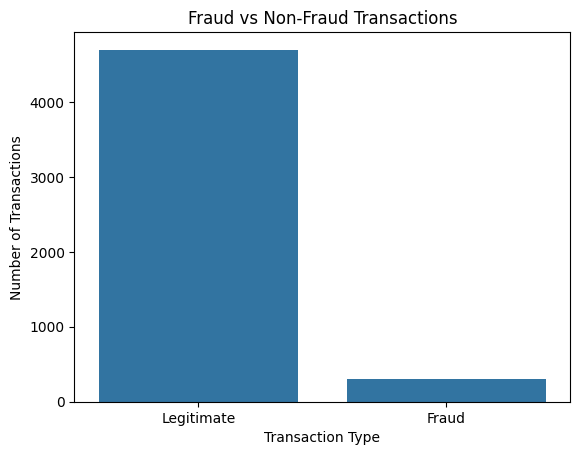


Training samples: 4000
Testing samples: 1000

Before SMOTE:
is_fraud
0    3757
1     243
Name: count, dtype: int64

After SMOTE:
is_fraud
0    3757
1    3757
Name: count, dtype: int64

XGBoost training completed!

RESULTS AT THRESHOLD = 0.50
Accuracy : 0.727
Precision: 0.0546
Recall   : 0.2131
F1 Score : 0.087
ROC-AUC  : 0.503

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.94      0.76      0.84       939
       Fraud       0.05      0.21      0.09        61

    accuracy                           0.73      1000
   macro avg       0.50      0.49      0.46      1000
weighted avg       0.88      0.73      0.79      1000



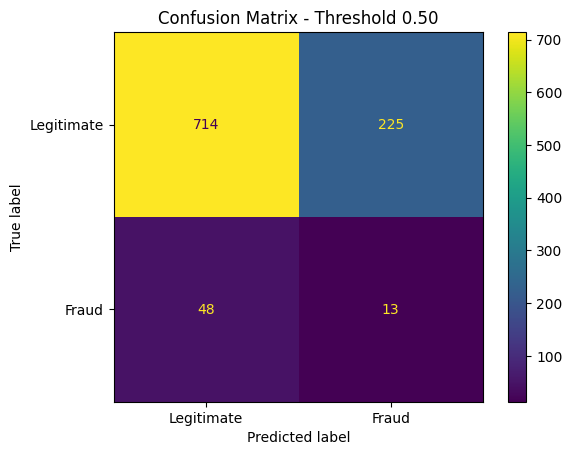

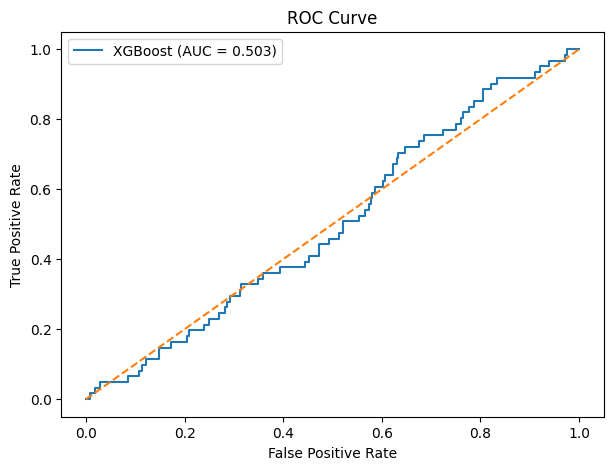


Threshold comparison:


,Threshold,Precision,Recall,F1
0,0.10,0.064267,0.819672,0.119190
1,0.15,0.065598,0.737705,0.120482
2,0.20,0.063725,0.639344,0.115899
3,0.25,0.058052,0.508197,0.104202
4,0.30,0.053763,0.409836,0.095057
5,0.35,0.056373,0.377049,0.098081
6,0.40,0.060000,0.344262,0.102190
7,0.45,0.058621,0.278689,0.096866
8,0.50,0.054622,0.213115,0.086957
9,0.55,0.051546,0.163934,0.078431



Best threshold based on F1 score: 0.15

RESULTS AT THRESHOLD = 0.15
Accuracy : 0.343
Precision: 0.0656
Recall   : 0.7377
F1 Score : 0.1205
ROC-AUC  : 0.503


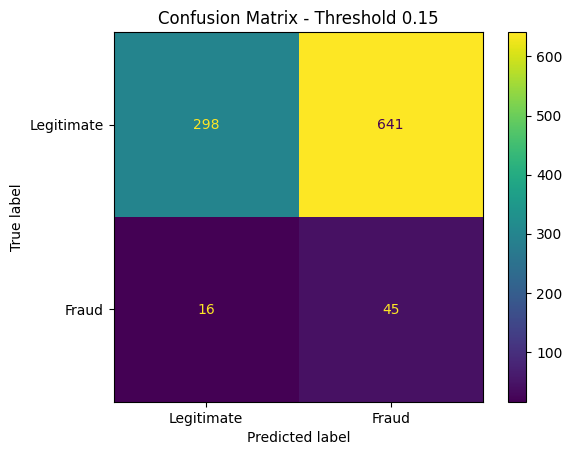


Feature Importance:


,Feature,Importance
7,failed_attempts,0.164798
6,device_changes,0.133730
4,transactions_last_24h,0.111640
9,new_device,0.104090
8,international_transaction,0.099838
1,transaction_hour,0.091262
0,transaction_amount,0.076430
2,account_age_days,0.074485
5,distance_from_home_km,0.072421
3,num_previous_transactions,0.071305


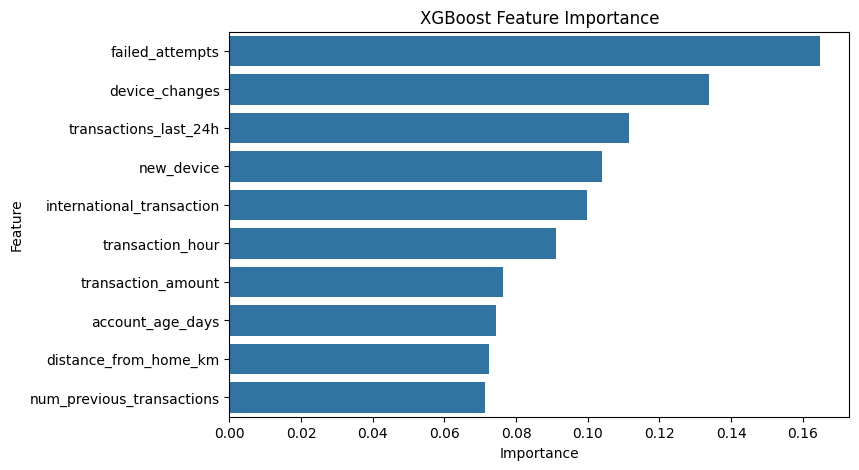


FINAL INTERPRETATION

This project demonstrates credit card fraud detection using XGBoost
on a simulated and highly imbalanced transaction dataset.

SMOTE was applied only to the training data to increase representation
of the minority fraud class.

XGBoost was then trained to classify transactions as legitimate or
fraudulent.

Because fraud detection is highly imbalanced, accuracy alone is not
sufficient. Precision, recall, F1-score and ROC-AUC are also examined.

The decision threshold was tuned using F1-score. Changing the threshold
changes the balance between detecting fraudulent transactions and
generating false alarms.

Feature importance scores from XGBoost provide an indication of which
transaction characteristics contributed most to the model's decisions.

IMPORTANT:
This dataset is simulated for educational purposes and does not
represent real banking transactions.



In [1]:
# ============================================================
# CREDIT CARD FRAUD DETECTION
# XGBoost + SMOTE + Decision Threshold Tuning
# ============================================================

# Install required libraries
!pip -q install xgboost imbalanced-learn

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

np.random.seed(42)

# ------------------------------------------------------------
# 2. CREATE A SMALL SIMULATED FRAUD DATASET
# ------------------------------------------------------------

n = 5000

data = {
    "transaction_amount": np.random.exponential(80, n),
    "transaction_hour": np.random.randint(0, 24, n),
    "account_age_days": np.random.randint(30, 3000, n),
    "num_previous_transactions": np.random.randint(1, 100, n),
    "transactions_last_24h": np.random.randint(0, 15, n),
    "distance_from_home_km": np.random.exponential(20, n),
    "device_changes": np.random.randint(0, 6, n),
    "failed_attempts": np.random.randint(0, 5, n),
    "international_transaction": np.random.randint(0, 2, n),
    "new_device": np.random.randint(0, 2, n)
}

df = pd.DataFrame(data)

# Create a small fraud probability
fraud_score = (
    0.015
    + 0.025 * (df["transaction_amount"] > 300)
    + 0.020 * (df["distance_from_home_km"] > 50)
    + 0.025 * (df["failed_attempts"] >= 3)
    + 0.025 * (df["new_device"] == 1)
    + 0.020 * (df["international_transaction"] == 1)
    + 0.020 * (df["device_changes"] >= 3)
)

# Keep probabilities within a reasonable range
fraud_score = np.clip(fraud_score, 0, 0.25)

df["is_fraud"] = np.random.binomial(1, fraud_score)

print("Dataset shape:", df.shape)

print("\nFirst 5 transactions:")
display(df.head())

print("\nClass distribution:")
print(df["is_fraud"].value_counts())

print("\nFraud percentage:",
      round(df["is_fraud"].mean() * 100, 2), "%")

# ------------------------------------------------------------
# 3. VISUALIZE CLASS IMBALANCE
# ------------------------------------------------------------

sns.countplot(x="is_fraud", data=df)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.show()

# ------------------------------------------------------------
# 4. PREPARE DATA
# ------------------------------------------------------------

X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

# ------------------------------------------------------------
# 5. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# ------------------------------------------------------------
# 6. APPLY SMOTE ONLY TO TRAINING DATA
# ------------------------------------------------------------

smote = SMOTE(
    random_state=42,
    k_neighbors=3
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nBefore SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# ------------------------------------------------------------
# 7. TRAIN XGBOOST MODEL
# ------------------------------------------------------------

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42
)

model.fit(X_train_smote, y_train_smote)

print("\nXGBoost training completed!")

# ------------------------------------------------------------
# 8. GET FRAUD PROBABILITIES
# ------------------------------------------------------------

y_prob = model.predict_proba(X_test)[:, 1]

# Default threshold = 0.50
y_pred_default = (y_prob >= 0.50).astype(int)

# ------------------------------------------------------------
# 9. DEFAULT MODEL EVALUATION
# ------------------------------------------------------------

print("\n================================")
print("RESULTS AT THRESHOLD = 0.50")
print("================================")

print("Accuracy :", round(accuracy_score(y_test, y_pred_default), 4))
print("Precision:", round(precision_score(y_test, y_pred_default, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred_default, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_default, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_default,
    target_names=["Legitimate", "Fraud"],
    zero_division=0
))

# ------------------------------------------------------------
# 10. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred_default)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
).plot()

plt.title("Confusion Matrix - Threshold 0.50")
plt.show()

# ------------------------------------------------------------
# 11. ROC CURVE
# ------------------------------------------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ------------------------------------------------------------
# 12. DECISION THRESHOLD TUNING
# ------------------------------------------------------------

thresholds_to_test = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds_to_test:

    predictions = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_results = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

print("\nThreshold comparison:")
display(threshold_results)

# Select threshold with highest F1
best_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best_threshold = best_row["Threshold"]

print(
    f"\nBest threshold based on F1 score: "
    f"{best_threshold:.2f}"
)

# ------------------------------------------------------------
# 13. EVALUATE AT BEST THRESHOLD
# ------------------------------------------------------------

y_pred_tuned = (
    y_prob >= best_threshold
).astype(int)

print("\n================================")
print(f"RESULTS AT THRESHOLD = {best_threshold:.2f}")
print("================================")

print(
    "Accuracy :",
    round(accuracy_score(y_test, y_pred_tuned), 4)
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            y_pred_tuned,
            zero_division=0
        ),
        4
    )
)

print(
    "Recall   :",
    round(
        recall_score(
            y_test,
            y_pred_tuned,
            zero_division=0
        ),
        4
    )
)

print(
    "F1 Score :",
    round(
        f1_score(
            y_test,
            y_pred_tuned,
            zero_division=0
        ),
        4
    )
)

print(
    "ROC-AUC  :",
    round(
        roc_auc_score(y_test, y_prob),
        4
    )
)

# ------------------------------------------------------------
# 14. TUNED CONFUSION MATRIX
# ------------------------------------------------------------

cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=["Legitimate", "Fraud"]
).plot()

plt.title(
    f"Confusion Matrix - Threshold {best_threshold:.2f}"
)

plt.show()

# ------------------------------------------------------------
# 15. FEATURE IMPORTANCE
# ------------------------------------------------------------

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("\nFeature Importance:")
display(importance)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# ------------------------------------------------------------
# 16. FINAL INTERPRETATION
# ------------------------------------------------------------

print("""
FINAL INTERPRETATION

This project demonstrates credit card fraud detection using XGBoost
on a simulated and highly imbalanced transaction dataset.

SMOTE was applied only to the training data to increase representation
of the minority fraud class.

XGBoost was then trained to classify transactions as legitimate or
fraudulent.

Because fraud detection is highly imbalanced, accuracy alone is not
sufficient. Precision, recall, F1-score and ROC-AUC are also examined.

The decision threshold was tuned using F1-score. Changing the threshold
changes the balance between detecting fraudulent transactions and
generating false alarms.

Feature importance scores from XGBoost provide an indication of which
transaction characteristics contributed most to the model's decisions.

IMPORTANT:
This dataset is simulated for educational purposes and does not
represent real banking transactions.
""")